# Reorder Risk Segmentation

This notebook builds on the cleaned supply chain inventory dataset from the first notebook.

The first analysis showed that `stockout_flag` is not usable because every record is coded as non-stockout. Because of that, this project uses reorder risk as the main planning signal. Reorder risk identifies records where inventory is at or below the reorder point.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Cleaned Dataset

The cleaned dataset was created in the first notebook and uploaded into this Colab session.

In [2]:
df = pd.read_csv("supply_chain_inventory_cleaned.csv")

df.head()

,date,sku_id,warehouse_id,supplier_id,region,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,...,month,month_year,inventory_buffer,reorder_risk_flag,forecast_error,absolute_forecast_error,revenue,gross_margin,inventory_buffer_group,forecast_bias
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,...,1,2024-01,213,0,1.48,1.48,204.80,65.30,High buffer,Under-forecasted
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,...,1,2024-01,196,0,-1.63,1.63,348.16,111.01,High buffer,Over-forecasted
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,...,1,2024-01,161,0,-4.62,4.62,716.80,228.55,High buffer,Over-forecasted
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,...,1,2024-01,137,0,4.57,4.57,491.52,156.72,High buffer,Under-forecasted
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,...,1,2024-01,116,0,2.30,2.30,430.08,137.13,High buffer,Under-forecasted


In [3]:
df.shape

(91250, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     91250 non-null  object 
 1   sku_id                   91250 non-null  object 
 2   warehouse_id             91250 non-null  object 
 3   supplier_id              91250 non-null  object 
 4   region                   91250 non-null  object 
 5   units_sold               91250 non-null  int64  
 6   inventory_level          91250 non-null  int64  
 7   supplier_lead_time_days  91250 non-null  int64  
 8   reorder_point            91250 non-null  int64  
 9   order_quantity           91250 non-null  int64  
 10  unit_cost                91250 non-null  float64
 11  unit_price               91250 non-null  float64
 12  promotion_flag           91250 non-null  int64  
 13  stockout_flag            91250 non-null  int64  
 14  demand_forecast       

## 3. Reorder Risk Baseline

I first review the overall reorder risk rate so later segment-level results have a baseline for comparison.

In [5]:
reorder_risk_counts = df["reorder_risk_flag"].value_counts().sort_index()

reorder_risk_counts

,count
reorder_risk_flag,
0,86209
1,5041


In [6]:
overall_reorder_risk_rate = df["reorder_risk_flag"].mean()

overall_reorder_risk_rate

np.float64(0.05524383561643836)

The overall reorder risk rate provides the benchmark for the rest of the notebook. Segments above this rate are more exposed than the dataset average, while segments below this rate appear less exposed.

## 4. SKU-Level Summary

This section summarizes reorder risk at the SKU level. This is more useful than only looking at broad regions or warehouses because SKU-level patterns can be hidden in larger operating segments.

In [7]:
sku_summary = (
    df.groupby("sku_id")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_units_sold=("units_sold", "mean"),
        avg_inventory_level=("inventory_level", "mean"),
        avg_reorder_point=("reorder_point", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        promotion_rate=("promotion_flag", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

sku_summary.head(10)

,records,total_units_sold,avg_units_sold,avg_inventory_level,avg_reorder_point,avg_inventory_buffer,avg_lead_time,avg_forecast_error,avg_absolute_forecast_error,promotion_rate,reorder_risk_rate
sku_id,,,,,,,,,,,
SKU_20,1825,36735,20.128767,470.461370,304.6,165.861370,5.0,-0.073381,2.333611,0.106849,0.058630
SKU_14,1825,36585,20.046575,445.760548,283.6,162.160548,8.8,-0.026932,2.317496,0.111781,0.058630
SKU_37,1825,36730,20.126027,465.055890,296.4,168.655890,7.2,-0.058844,2.355019,0.098082,0.057534
SKU_22,1825,36646,20.080000,457.368767,290.8,166.568767,6.0,-0.067912,2.415704,0.113973,0.056986
SKU_17,1825,36449,19.972055,490.636712,328.2,162.436712,7.8,0.018274,2.423764,0.098630,0.056986
SKU_18,1825,37234,20.402192,463.699726,294.6,169.099726,8.0,0.028619,2.402099,0.110685,0.056986
SKU_10,1825,36579,20.043288,459.178082,292.6,166.578082,10.2,-0.029211,2.415337,0.109041,0.056438
SKU_39,1825,36583,20.045479,499.740274,331.8,167.940274,7.4,0.067819,2.327600,0.095342,0.056438
SKU_3,1825,36785,20.156164,443.609315,273.4,170.209315,10.6,-0.134860,2.369447,0.108493,0.056438


### SKU-Level Notes

At the SKU level, reorder risk is fairly narrow across the highest-ranked products. The top SKUs are around 5.6% to 5.9% reorder risk, which is only slightly above the overall dataset rate of 5.52%.

In [8]:
sku_summary["reorder_risk_rate"].describe()

,reorder_risk_rate
count,50.000000
mean,0.055244
std,0.001408
min,0.051507
25%,0.054247
50%,0.055342
75%,0.056301
max,0.058630


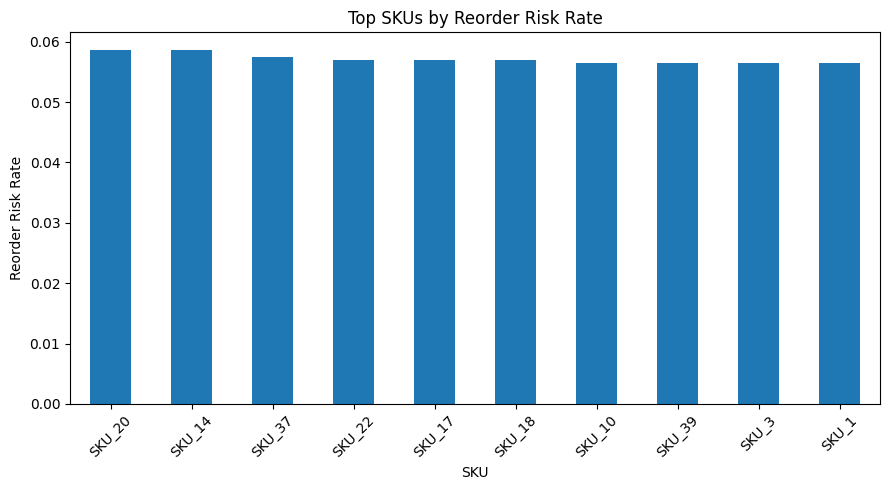

In [9]:
sku_summary.head(10)["reorder_risk_rate"].plot(kind="bar", figsize=(9, 5))

plt.title("Top SKUs by Reorder Risk Rate")
plt.xlabel("SKU")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. SKU-Warehouse Summary

This section reviews reorder risk at the SKU-warehouse level. This gives a more operational view because the same SKU may not behave the same way across all warehouse locations.

In [10]:
sku_warehouse_summary = (
    df.groupby(["sku_id", "warehouse_id"])
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_units_sold=("units_sold", "mean"),
        avg_inventory_level=("inventory_level", "mean"),
        avg_reorder_point=("reorder_point", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        promotion_rate=("promotion_flag", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .reset_index()
    .sort_values("reorder_risk_rate", ascending=False)
)

sku_warehouse_summary.head(10)

,sku_id,warehouse_id,records,total_units_sold,avg_units_sold,avg_inventory_level,avg_reorder_point,avg_inventory_buffer,avg_lead_time,avg_forecast_error,avg_absolute_forecast_error,promotion_rate,reorder_risk_rate
49,SKU_18,WH_5,365,7533,20.638356,541.405479,394.0,147.405479,13.0,-0.319890,2.449205,0.095890,0.065753
16,SKU_12,WH_2,365,7351,20.139726,517.175342,370.0,147.175342,6.0,-0.112630,2.461616,0.095890,0.063014
26,SKU_14,WH_2,365,7413,20.309589,419.369863,268.0,151.369863,14.0,-0.132164,2.275616,0.126027,0.063014
60,SKU_20,WH_1,365,7508,20.569863,453.169863,295.0,158.169863,9.0,-0.050493,2.410329,0.106849,0.063014
74,SKU_22,WH_5,365,7280,19.945205,470.643836,326.0,144.643836,4.0,-0.189562,2.514055,0.131507,0.063014
157,SKU_38,WH_3,365,7443,20.391781,494.654795,344.0,150.654795,8.0,0.038082,2.335178,0.109589,0.063014
238,SKU_7,WH_4,365,7377,20.210959,406.761644,253.0,153.761644,4.0,0.027918,2.394493,0.076712,0.063014
243,SKU_8,WH_4,365,7423,20.336986,546.306849,395.0,151.306849,7.0,0.068493,2.288329,0.117808,0.063014
28,SKU_14,WH_4,365,7185,19.684932,496.065753,343.0,153.065753,10.0,0.039260,2.339425,0.101370,0.060274
44,SKU_17,WH_5,365,7381,20.221918,475.254795,321.0,154.254795,8.0,0.108110,2.422247,0.065753,0.060274


### SKU-Warehouse Notes

The SKU-warehouse view creates a more useful planning lens than SKU alone. The highest reorder risk rates appear around 6.0% to 6.6%, compared with the overall baseline of 5.52%.

The highest-risk combinations generally have lower average inventory buffers than the dataset average.

In [11]:
sku_warehouse_summary["reorder_risk_rate"].describe()

,reorder_risk_rate
count,250.000000
mean,0.055244
std,0.003314
min,0.049315
25%,0.052055
50%,0.054795
75%,0.057534
max,0.065753


## 6. Promotion and Forecast Review

The first notebook showed that promoted records had higher reorder risk than non-promoted records. This section keeps promotion and forecast error in the segmentation view.

In [12]:
promotion_summary = (
    df.groupby("promotion_flag")
    .agg(
        records=("reorder_risk_flag", "size"),
        avg_units_sold=("units_sold", "mean"),
        avg_demand_forecast=("demand_forecast", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
)

promotion_summary

,records,avg_units_sold,avg_demand_forecast,avg_forecast_error,avg_absolute_forecast_error,avg_inventory_buffer,reorder_risk_rate
promotion_flag,,,,,,,
0,81980,19.504977,19.534176,-0.029199,2.382167,172.015736,0.053354
1,9270,24.914887,24.927057,-0.012170,2.359033,166.489320,0.071953


In [13]:
forecast_bias_summary = (
    df.groupby("forecast_bias")
    .agg(
        records=("reorder_risk_flag", "size"),
        avg_units_sold=("units_sold", "mean"),
        avg_demand_forecast=("demand_forecast", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

forecast_bias_summary

,records,avg_units_sold,avg_demand_forecast,avg_forecast_error,avg_absolute_forecast_error,avg_inventory_buffer,reorder_risk_rate
forecast_bias,,,,,,,
Under-forecasted,45160,20.242936,17.866367,2.376569,2.376569,170.971391,0.056067
Over-forecasted,45649,19.999474,22.405494,-2.406020,2.406020,171.855397,0.054744
Neutral,441,6.467120,6.467120,0.000000,0.000000,179.390023,0.022676


## 7. Monthly Reorder Risk

The first notebook suggested that monthly variation may be more meaningful than broad region, warehouse, or supplier differences. This section keeps that time pattern visible.

In [14]:
monthly_summary = (
    df.groupby("month_year")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_units_sold=("units_sold", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        promotion_rate=("promotion_flag", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .reset_index()
)

monthly_summary

,month_year,records,total_units_sold,avg_units_sold,avg_inventory_buffer,avg_absolute_forecast_error,promotion_rate,reorder_risk_rate
0,2024-01,7750,176681,22.797548,227.401935,2.399005,0.105032,0.041935
1,2024-02,7250,197188,27.198345,159.880000,2.416770,0.094621,0.078069
2,2024-03,7750,231596,29.883355,159.000387,2.392874,0.104516,0.083355
3,2024-04,7500,223793,29.839067,154.349600,2.375808,0.102667,0.084667
4,2024-05,7750,210841,27.205290,159.013161,2.402512,0.102968,0.077935
5,2024-06,7500,170013,22.668400,160.421733,2.400492,0.096533,0.067333
6,2024-07,7750,134915,17.408387,166.436129,2.412947,0.107742,0.050323
7,2024-08,7750,99019,12.776645,177.419871,2.387403,0.101032,0.034968
8,2024-09,7500,76304,10.173867,172.253067,2.319481,0.098800,0.030000
9,2024-10,7750,79599,10.270839,175.652129,2.298237,0.106452,0.028774


### Monthly Notes

Monthly patterns are more pronounced than the broad region, warehouse, supplier, or SKU-level differences. Reorder risk is highest from February through April, with April reaching 8.47%.

January has the largest average inventory buffer and a lower reorder risk rate. From February through May, average inventory buffer drops sharply while reorder risk rises.

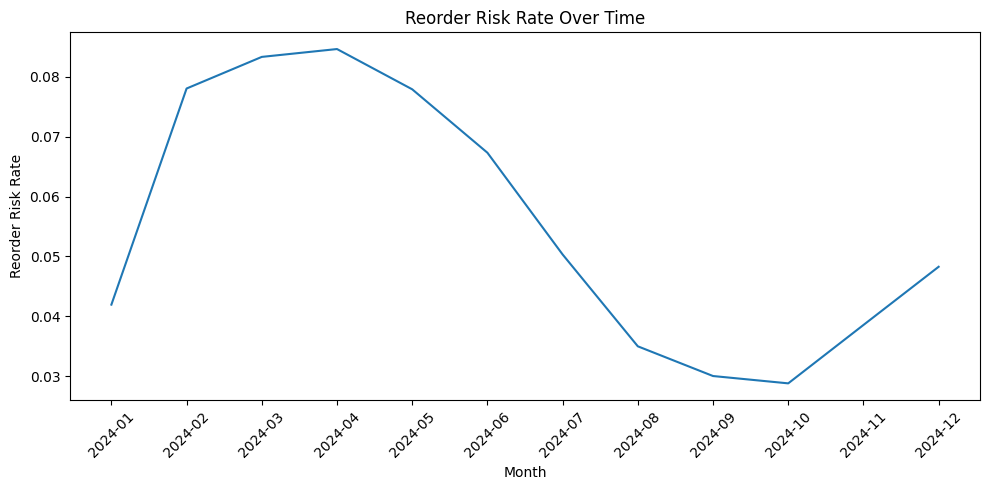

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month_year"], monthly_summary["reorder_risk_rate"])

plt.title("Reorder Risk Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Create Risk Segments

I created simple reorder risk segments using the SKU-warehouse summary.

In [16]:
sku_warehouse_summary["risk_segment"] = pd.qcut(
    sku_warehouse_summary["reorder_risk_rate"],
    q=4,
    labels=[
        "Lowest risk",
        "Lower-mid risk",
        "Upper-mid risk",
        "Highest risk"
    ],
    duplicates="drop"
)

sku_warehouse_summary["risk_segment"].value_counts()

,count
risk_segment,
Lowest risk,81
Lower-mid risk,76
Upper-mid risk,58
Highest risk,35


In [17]:
risk_segment_summary = (
    sku_warehouse_summary.groupby("risk_segment", observed=False)
    .agg(
        sku_warehouse_records=("reorder_risk_rate", "size"),
        avg_reorder_risk_rate=("reorder_risk_rate", "mean"),
        avg_inventory_buffer=("avg_inventory_buffer", "mean"),
        avg_units_sold=("avg_units_sold", "mean"),
        avg_lead_time=("avg_lead_time", "mean"),
        avg_absolute_forecast_error=("avg_absolute_forecast_error", "mean"),
        avg_promotion_rate=("promotion_rate", "mean")
    )
)

risk_segment_summary

,sku_warehouse_records,avg_reorder_risk_rate,avg_inventory_buffer,avg_units_sold,avg_lead_time,avg_absolute_forecast_error,avg_promotion_rate
risk_segment,,,,,,,
Lowest risk,81,0.051547,182.092237,19.999763,7.901235,2.383695,0.101539
Lower-mid risk,76,0.054795,171.187311,20.038320,7.815789,2.379772,0.101370
Upper-mid risk,58,0.057534,165.381105,20.073359,8.637931,2.385016,0.101086
Highest risk,35,0.060978,157.479061,20.185519,7.457143,2.362322,0.103014


### Risk Segment Notes

The risk segments show a clear but moderate gradient. The highest-risk segment has an average reorder risk rate of 6.10%, compared with 5.15% in the lowest-risk segment.

The highest-risk segment also has the lowest average inventory buffer. This pattern is consistent with the project logic: lower inventory buffer is associated with higher reorder risk.

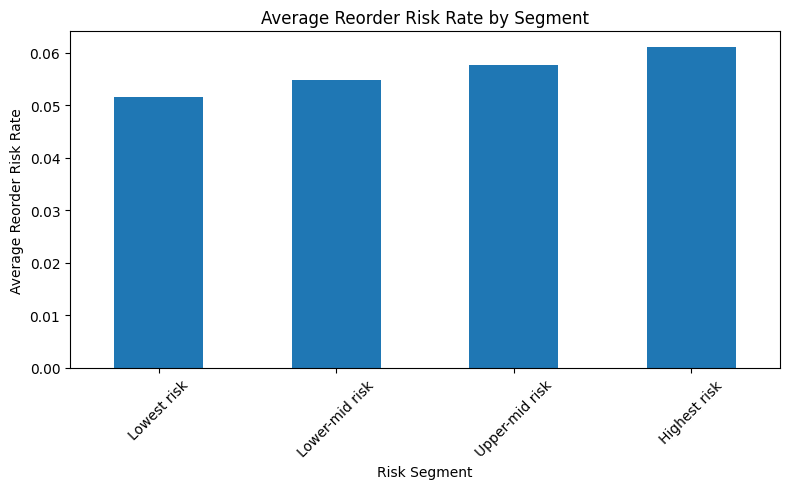

In [18]:
risk_segment_summary["avg_reorder_risk_rate"].plot(kind="bar", figsize=(8, 5))

plt.title("Average Reorder Risk Rate by Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Average Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Identify Highest-Risk SKU-Warehouse Records

This table isolates the SKU-warehouse combinations with the highest reorder risk rates.

In [19]:
highest_risk_sku_warehouse = (
    sku_warehouse_summary
    .sort_values(
        ["reorder_risk_rate", "avg_inventory_buffer", "total_units_sold"],
        ascending=[False, True, False]
    )
    .head(20)
)

highest_risk_sku_warehouse

,sku_id,warehouse_id,records,total_units_sold,avg_units_sold,avg_inventory_level,avg_reorder_point,avg_inventory_buffer,avg_lead_time,avg_forecast_error,avg_absolute_forecast_error,promotion_rate,reorder_risk_rate,risk_segment
49,SKU_18,WH_5,365,7533,20.638356,541.405479,394.0,147.405479,13.0,-0.319890,2.449205,0.095890,0.065753,Highest risk
74,SKU_22,WH_5,365,7280,19.945205,470.643836,326.0,144.643836,4.0,-0.189562,2.514055,0.131507,0.063014,Highest risk
16,SKU_12,WH_2,365,7351,20.139726,517.175342,370.0,147.175342,6.0,-0.112630,2.461616,0.095890,0.063014,Highest risk
157,SKU_38,WH_3,365,7443,20.391781,494.654795,344.0,150.654795,8.0,0.038082,2.335178,0.109589,0.063014,Highest risk
243,SKU_8,WH_4,365,7423,20.336986,546.306849,395.0,151.306849,7.0,0.068493,2.288329,0.117808,0.063014,Highest risk
26,SKU_14,WH_2,365,7413,20.309589,419.369863,268.0,151.369863,14.0,-0.132164,2.275616,0.126027,0.063014,Highest risk
238,SKU_7,WH_4,365,7377,20.210959,406.761644,253.0,153.761644,4.0,0.027918,2.394493,0.076712,0.063014,Highest risk
60,SKU_20,WH_1,365,7508,20.569863,453.169863,295.0,158.169863,9.0,-0.050493,2.410329,0.106849,0.063014,Highest risk
69,SKU_21,WH_5,365,7371,20.194521,459.131507,309.0,150.131507,8.0,-0.230055,2.283041,0.120548,0.060274,Highest risk
34,SKU_15,WH_5,365,7333,20.090411,430.578082,279.0,151.578082,14.0,-0.142521,2.329973,0.090411,0.060274,Highest risk


### Highest-Risk SKU-Warehouse Notes

The highest-risk SKU-warehouse combinations are useful as a planning review list. These records do not imply confirmed stockouts, but they identify product-location combinations with the highest share of days at or below the reorder point.

Several of the highest-risk combinations have average inventory buffers around 145 to 155 units, which is lower than the overall average buffer of 171.45 units.

In [20]:
sku_summary.to_csv("sku_summary.csv")
sku_warehouse_summary.to_csv("sku_warehouse_summary.csv", index=False)
risk_segment_summary.to_csv("risk_segment_summary.csv")
highest_risk_sku_warehouse.to_csv("highest_risk_sku_warehouse.csv", index=False)
monthly_summary.to_csv("monthly_summary.csv", index=False)
promotion_summary.to_csv("promotion_summary.csv")
forecast_bias_summary.to_csv("forecast_bias_summary.csv")

In [21]:
from google.colab import files

files.download("sku_summary.csv")
files.download("sku_warehouse_summary.csv")
files.download("risk_segment_summary.csv")
files.download("highest_risk_sku_warehouse.csv")
files.download("monthly_summary.csv")
files.download("promotion_summary.csv")
files.download("forecast_bias_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notebook Summary

The SKU-level and supplier-level differences are modest, which suggests that reorder risk is not concentrated in one obvious product or supplier group. The SKU-warehouse view is more useful because it gives a product-location planning lens. The highest-risk SKU-warehouse combinations reach reorder risk rates around 6.0% to 6.6%, compared with the overall baseline of 5.52%.

The clearest pattern is monthly. Reorder risk rises from February through April while average inventory buffer falls, suggesting that timing and demand seasonality may matter more than broad region, warehouse, or supplier differences.

The risk segments are useful for prioritization rather than prediction. The highest-risk segment has a higher reorder risk rate and a lower average inventory buffer than the lowest-risk segment. These segments can support a Tableau dashboard focused on replenishment review and inventory planning attention.